In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings("ignore")

In [158]:
df = pd.read_csv('student_performance_interactions.csv')
df

,student_id,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,S0001,60.137241,D,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,Master,Noisy
1,S0002,99.021977,A,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,High School,Quiet
2,S0003,70.522955,C,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,High School,Moderate
3,S0004,63.448537,D,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,High School,Noisy
4,S0005,66.483019,C,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,Master,Quiet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S0996,59.206313,D,1,45.037014,38.436901,43.612637,47.394726,4.638258,69.249006,96.251273,6.816746,4.582381,64.714504,9.342533,2.890583,Bachelor,Noisy
996,S0997,79.122551,C,1,90.452247,87.393401,89.171348,81.296522,2.078520,84.259602,67.662648,7.933475,2.932469,111.320337,5.620030,3.687013,Master,Quiet
997,S0998,50.601257,D,1,47.525025,47.339841,46.317537,41.382806,4.278708,71.120438,96.521984,7.501127,2.056315,51.508793,4.209895,6.816193,Master,Noisy
998,S0999,89.253071,B,1,92.263054,90.116543,91.954233,81.885114,4.997401,86.022243,100.131470,6.557973,4.163385,48.586185,5.566401,5.277389,High School,Noisy


In [159]:
df.shape[0]    #length of the dataset

1000

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 1000 non-null   object 
 1   final_score                1000 non-null   float64
 2   grade                      1000 non-null   object 
 3   pass_fail                  1000 non-null   int64  
 4   previous_score             1000 non-null   float64
 5   math_prev_score            1000 non-null   float64
 6   science_prev_score         1000 non-null   float64
 7   language_prev_score        1000 non-null   float64
 8   daily_study_hours          1000 non-null   float64
 9   attendance_percentage      1000 non-null   float64
 10  homework_completion_rate   1000 non-null   float64
 11  sleep_hours                1000 non-null   float64
 12  screen_time_hours          1000 non-null   float64
 13  physical_activity_minutes  1000 non-null   float6

In [161]:
df.drop('student_id', axis=1, inplace=True)

In [162]:
df.isnull().sum()

final_score                  0
grade                        0
pass_fail                    0
previous_score               0
math_prev_score              0
science_prev_score           0
language_prev_score          0
daily_study_hours            0
attendance_percentage        0
homework_completion_rate     0
sleep_hours                  0
screen_time_hours            0
physical_activity_minutes    0
motivation_score             0
exam_anxiety_score           0
parent_education_level       0
study_environment            0
dtype: int64

In [163]:
df.duplicated().sum()

np.int64(0)

In [164]:
df['pass_fail'].value_counts()

pass_fail
1    930
0     70
Name: count, dtype: int64

In [165]:
df.describe()   # there is no skewnwss if the value of mean and median varries within -0.5 to 0.5 

,final_score,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,70.935159,0.930000,66.964110,67.458590,67.033210,66.906063,2.984155,73.275703,79.755579,6.964696,3.475139,75.914922,6.973272,3.167954
std,14.376419,0.255275,16.067555,16.593689,17.105514,16.705229,1.158047,9.533937,12.360754,0.684015,1.395155,25.777316,1.780761,1.806371
min,37.364699,0.000000,40.254761,30.235250,25.752553,27.176600,1.003774,47.445725,51.604853,4.500750,1.000264,30.220913,4.000946,1.000000
25%,60.079082,1.000000,52.978530,53.098000,52.509398,53.562773,1.985539,66.256237,69.964528,6.518039,2.318330,54.076377,5.427378,1.369204
50%,70.673531,1.000000,67.324406,67.561105,66.133873,66.693546,2.934717,73.328172,79.393715,6.976139,3.472257,75.819676,6.910094,3.098631
75%,81.830057,1.000000,80.937577,81.380928,81.319085,80.269633,3.971015,80.230732,89.592788,7.413489,4.618956,98.505332,8.577936,4.600374
max,100.000000,1.000000,94.984472,104.984169,107.432492,107.561521,4.997401,99.111497,110.485203,9.353503,5.984953,119.970588,9.992500,8.535907


In [166]:
num_cols = df.select_dtypes(include=['int','float'])

final_score


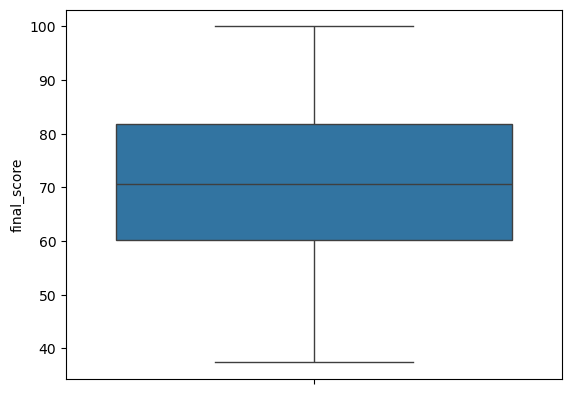

pass_fail


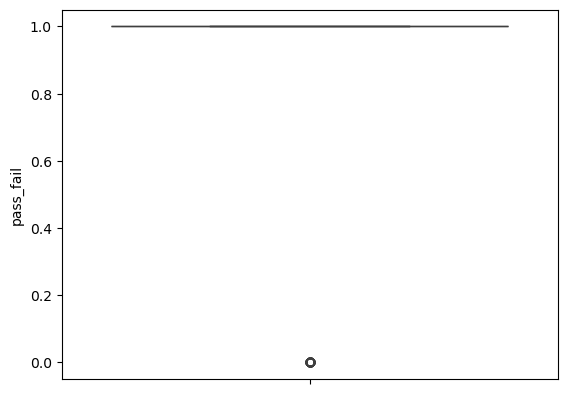

previous_score


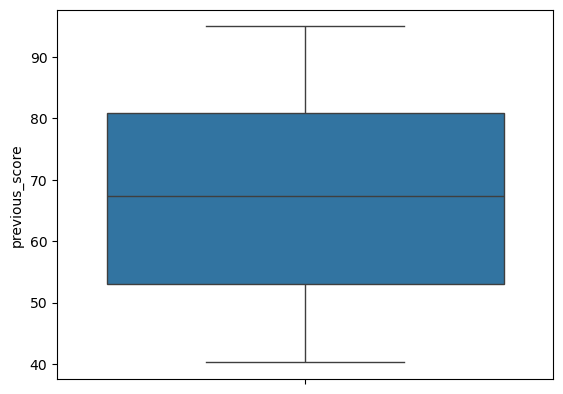

math_prev_score


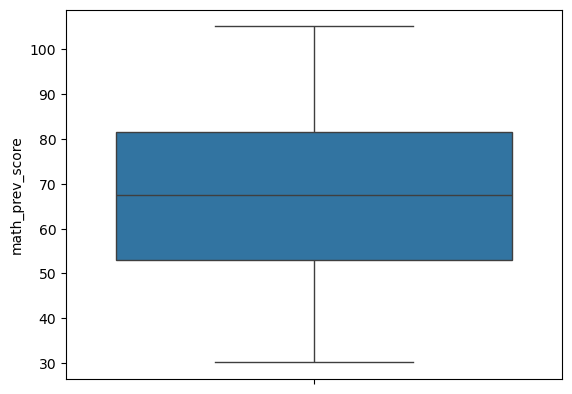

science_prev_score


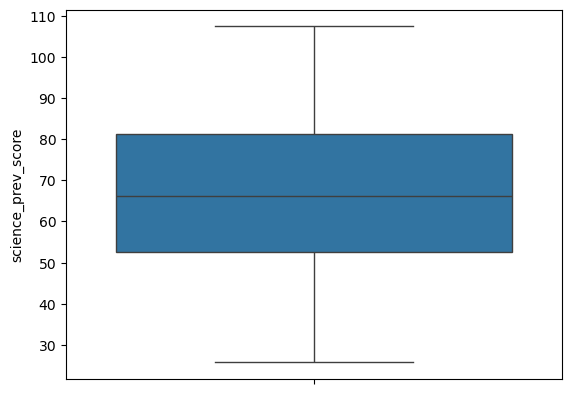

language_prev_score


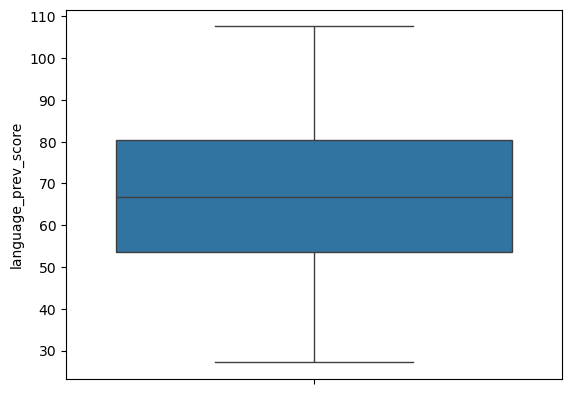

daily_study_hours


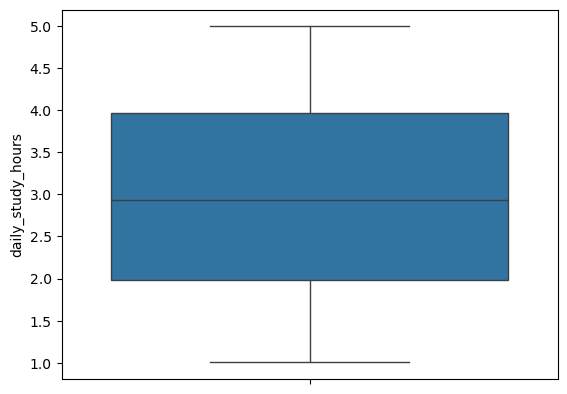

attendance_percentage


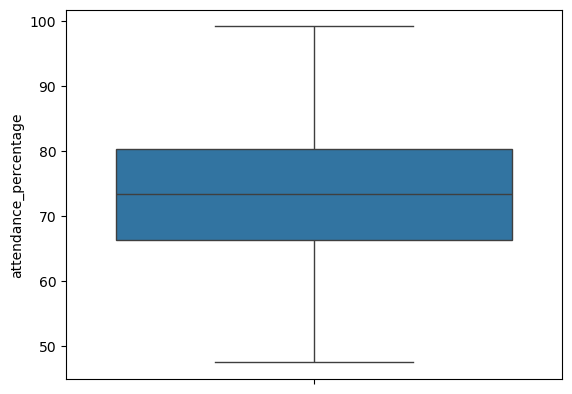

homework_completion_rate


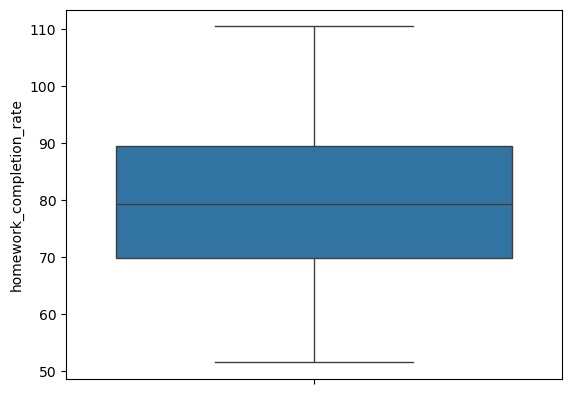

sleep_hours


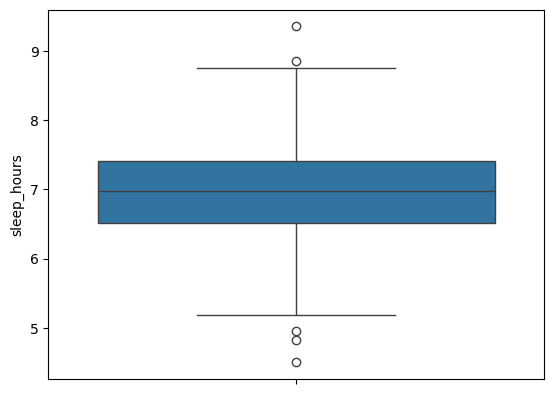

screen_time_hours


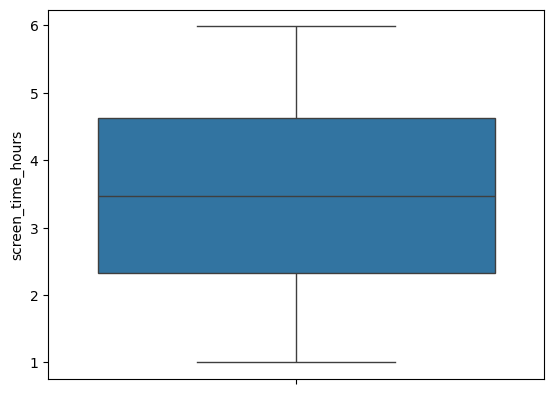

physical_activity_minutes


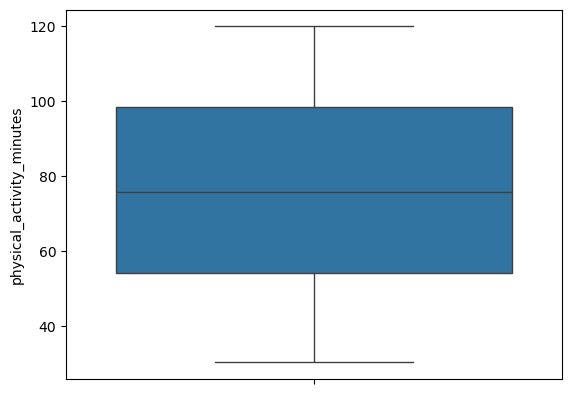

motivation_score


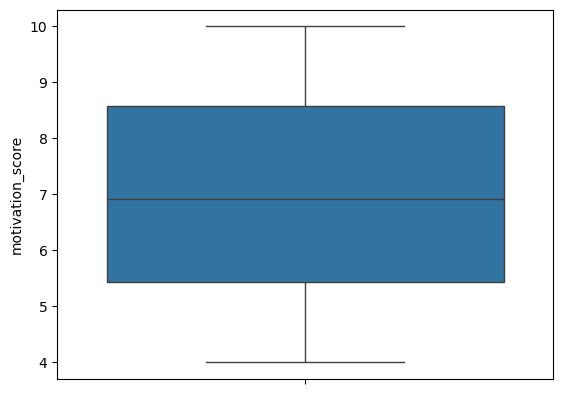

exam_anxiety_score


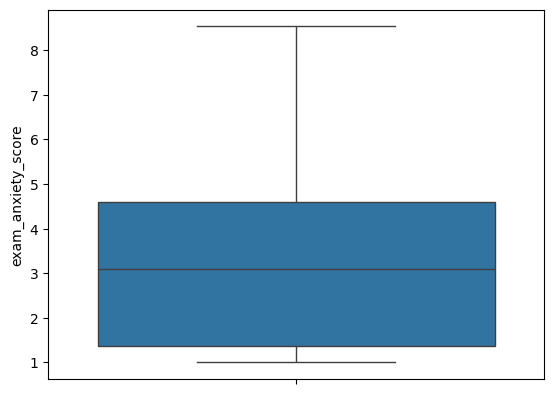

In [167]:
for i in num_cols:
    print(f"{i}")
    sns.boxplot(df[i])
    plt.show()

In [168]:
from scipy.stats import skew 
for i in num_cols:
    print(f"{i} : {skew(df[i])}")

# there is no skewness as the range of all the skewness of the data is between -0.5 to 0.5 

final_score : 0.03417705208293178
pass_fail : -3.370605747179369
previous_score : 0.03878561155805293
math_prev_score : 0.020636808159459143
science_prev_score : 0.06477847068510374
language_prev_score : 0.045821038484474864
daily_study_hours : 0.05393131570238982
attendance_percentage : -0.010113674072334928
homework_completion_rate : 0.06602405034579352
sleep_hours : -0.02098651984884919
screen_time_hours : 0.03514393101710646
physical_activity_minutes : -0.04952985430792189
motivation_score : 0.054691057209001456
exam_anxiety_score : 0.37916748596090405


In [169]:
obj_cols = df.select_dtypes('object')
obj_cols

,grade,parent_education_level,study_environment
0,D,Master,Noisy
1,A,High School,Quiet
2,C,High School,Moderate
3,D,High School,Noisy
4,C,Master,Quiet
...,...,...,...
995,D,Bachelor,Noisy
996,C,Master,Quiet
997,D,Master,Noisy
998,B,High School,Noisy


In [170]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for i in obj_cols:
    df[i] = le.fit_transform(df[i])
df.head()

,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,60.137241,3,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,2,1
1,99.021977,0,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,1,2
2,70.522955,2,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,1,0
3,63.448537,3,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,1,1
4,66.483019,2,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,2,2


In [171]:
df["grade"].value_counts()

grade
2    338
3    304
1    182
0    106
4     70
Name: count, dtype: int64

In [172]:
from imblearn.over_sampling import SMOTE

X = df.drop(columns=["pass_fail"])
y = df["pass_fail"]

smote = SMOTE(random_state=1)

features, target = smote.fit_resample(X,y)
target.value_counts()


pass_fail
1    930
0    930
Name: count, dtype: int64

In [173]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, target,test_size=0.25,random_state=1)


In [174]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [175]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)

y_pred_log = log_model.predict(x_test_scaled)


In [176]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Accuracy: 1.0
[[226   0]
 [  0 239]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       226
           1       1.00      1.00      1.00       239

    accuracy                           1.00       465
   macro avg       1.00      1.00      1.00       465
weighted avg       1.00      1.00      1.00       465



In [177]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=1)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)


In [178]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=1,class_weight='balanced')
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)


In [179]:
def mymodel(model):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    labels = model.classes_
    # checking for overfit and underfit
    print(f'Training Score : {round(model.score(x_train, y_train),2)}')
    print(f'Testing Score : {model.score(x_test, y_test)}')
    # evaluation metrics
    c = pd.DataFrame(confusion_matrix(y_test, y_pred),
                     index = labels,
                     columns = labels)
    print(f'Confusion Matrix : \n{c}')
    print(f'Classification Report : \n{classification_report(y_test, y_pred)}')
    return model

In [180]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced')
mymodel(rf)

Training Score : 1.0
Testing Score : 1.0
Confusion Matrix : 
     0    1
0  226    0
1    0  239
Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       226
           1       1.00      1.00      1.00       239

    accuracy                           1.00       465
   macro avg       1.00      1.00      1.00       465
weighted avg       1.00      1.00      1.00       465



RandomForestClassifier(class_weight='balanced')

In [181]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)

print("XGBoost Precision:", precision_score(y_test, xgb_pred, average='weighted'))
print(classification_report(y_test, xgb_pred))


XGBoost Precision: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       226
           1       1.00      1.00      1.00       239

    accuracy                           1.00       465
   macro avg       1.00      1.00      1.00       465
weighted avg       1.00      1.00      1.00       465



In [182]:
from sklearn.metrics import confusion_matrix, classification_report,precision_score

In [183]:
print(accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


1.0
[[226   0]
 [  0 239]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       226
           1       1.00      1.00      1.00       239

    accuracy                           1.00       465
   macro avg       1.00      1.00      1.00       465
weighted avg       1.00      1.00      1.00       465



In [184]:
pd.DataFrame({
    "Feature": features.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)


,Feature,Importance
1,grade,0.343589
0,final_score,0.309822
3,math_prev_score,0.107492
2,previous_score,0.099664
4,science_prev_score,0.043787
7,attendance_percentage,0.031734
5,language_prev_score,0.027988
14,parent_education_level,0.008922
6,daily_study_hours,0.006620
8,homework_completion_rate,0.005743


In [185]:
final_model = rf

import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(final_model, f)